In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import metrics
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
df = pd.read_csv('train.csv')
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [3]:
df = df.drop(['CustomerId', 'Surname', 'Geography', 'HasCrCard', 'id', 'Tenure', 'EstimatedSalary', 'EstimatedSalary', 'CreditScore'], axis=1)
df = pd.get_dummies(df)

In [4]:
x = df.drop('Exited', axis=1)
y = df['Exited']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

              precision    recall  f1-score   support

           0       0.84      0.96      0.90     26023
           1       0.67      0.34      0.45      6984

    accuracy                           0.83     33007
   macro avg       0.76      0.65      0.67     33007
weighted avg       0.81      0.83      0.80     33007

Model aniqligi: 0.8254612657921047


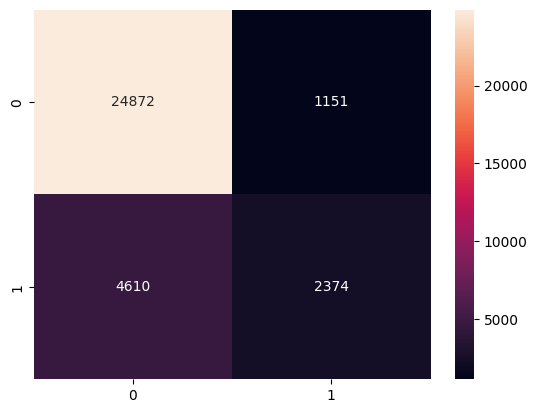

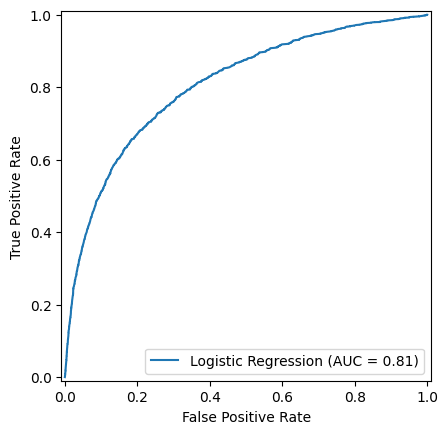

In [5]:
# Train model
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)

# Prediction
y_pred = lr_model.predict(x_test)

# Classification report
lr_model_report = metrics.classification_report(y_test, y_pred)
lr_model_accuracy = metrics.accuracy_score(y_test, y_pred)
print(lr_model_report)
print("Model aniqligi:", lr_model_accuracy)

# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

# ROC Curve
y_pred_proba = lr_model.predict_proba(x_test)[:, 1]  # ✅ lr_model
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="Logistic Regression")
display.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     26023
           1       0.77      0.47      0.58      6984

    accuracy                           0.86     33007
   macro avg       0.82      0.72      0.75     33007
weighted avg       0.85      0.86      0.84     33007

Model aniqligi: 0.8576362589753689


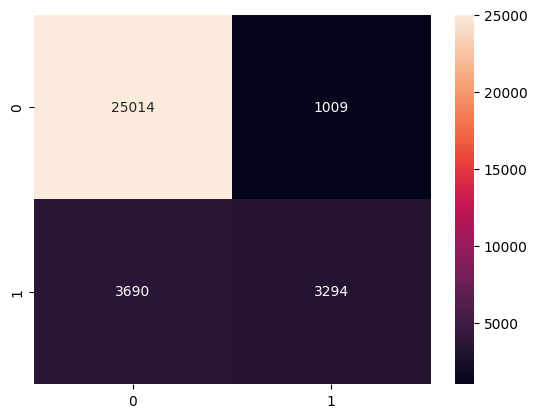

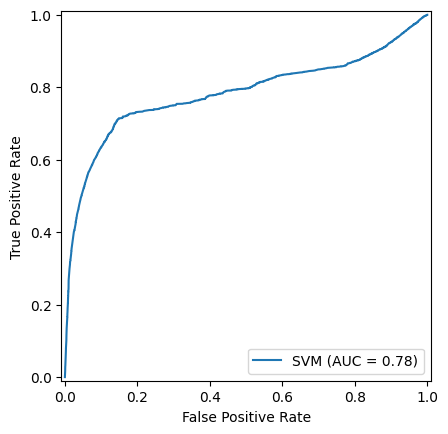

In [6]:
# Train model
svm = SVC(probability=True)
svm.fit(x_train, y_train)

# Prediction
y_pred = svm.predict(x_test)
# Classification report
svm_report = metrics.classification_report(y_test, y_pred)
svm_accuracy = metrics.accuracy_score(y_test, y_pred)
print(svm_report)
print("Model aniqligi:", svm_accuracy)

# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

# ROC Curve
y_pred_proba = svm.predict_proba(x_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="SVM")
display.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.88      0.90      0.89     26023
           1       0.59      0.52      0.55      6984

    accuracy                           0.82     33007
   macro avg       0.73      0.71      0.72     33007
weighted avg       0.82      0.82      0.82     33007

Model aniqligi: 0.8220680461720241


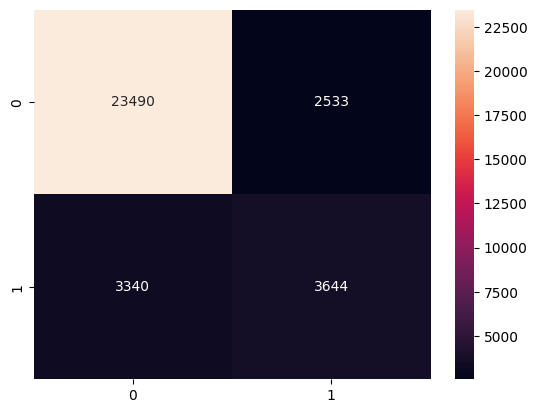

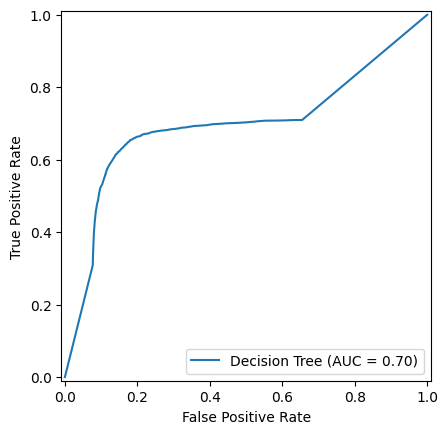

In [7]:
# Train model
tree = DecisionTreeClassifier()
tree.fit(x_train, y_train)

# Prediction
y_pred = tree.predict(x_test)

# Classification report
tree_report = metrics.classification_report(y_test, y_pred)
tree_accuracy = metrics.accuracy_score(y_test, y_pred)
print(tree_report)
print("Model aniqligi:", tree_accuracy)

# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

# ROC Curve
y_pred_proba = tree.predict_proba(x_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="Decision Tree")
display.plot()
plt.show()


              precision    recall  f1-score   support

           0       0.88      0.91      0.89     26023
           1       0.61      0.53      0.57      6984

    accuracy                           0.83     33007
   macro avg       0.74      0.72      0.73     33007
weighted avg       0.82      0.83      0.82     33007

Model aniqligi: 0.8284303329596753


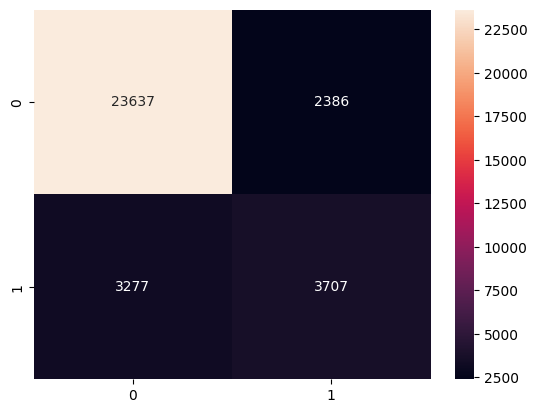

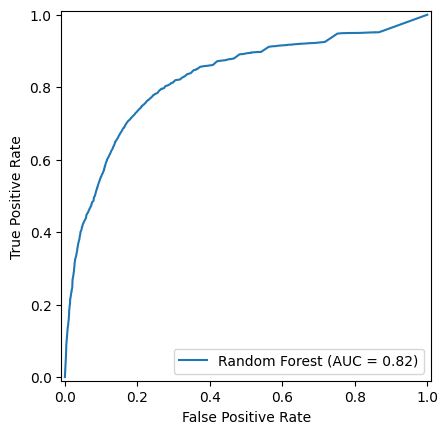

In [8]:
# Train model
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)

# Prediction
y_pred = rf_model.predict(x_test)


# Classification report
rf_model_report = metrics.classification_report(y_test, y_pred)
rf_model_accuracy = metrics.accuracy_score(y_test, y_pred)
print(rf_model_report)
print("Model aniqligi:", rf_model_accuracy)

# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

# ROC Curve
y_pred_proba = rf_model.predict_proba(x_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="Random Forest")
display.plot()
plt.show()

In [9]:
# Report

# Linear Regression
print("Linear Regression results")
print(lr_model_report)
print("Model aniqliligi:",lr_model_accuracy)

# SVM
print("Support Vector Machine results")
print(svm_report)
print("Model aniqliligi:", svm_accuracy)

# Decision Tree
print("Decision Tree results")
print(tree_report)
print("Model aniqliligi:", tree_accuracy)

# Random Forest
print("Random Forest results")
print(rf_model_report)
print("Model aniqliligi:", rf_model_accuracy)

Linear Regression results
              precision    recall  f1-score   support

           0       0.84      0.96      0.90     26023
           1       0.67      0.34      0.45      6984

    accuracy                           0.83     33007
   macro avg       0.76      0.65      0.67     33007
weighted avg       0.81      0.83      0.80     33007

Model aniqliligi: 0.8254612657921047
Support Vector Machine results
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     26023
           1       0.77      0.47      0.58      6984

    accuracy                           0.86     33007
   macro avg       0.82      0.72      0.75     33007
weighted avg       0.85      0.86      0.84     33007

Model aniqliligi: 0.8576362589753689
Decision Tree results
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     26023
           1       0.59      0.52      0.55      6984

    accuracy                 

In [10]:
# Predict test dataset
test_df = pd.read_csv('test.csv')
test_ids = test_df['CustomerId'].copy()
test_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00


In [11]:
test_df = test_df.drop(columns=['CustomerId', 'Surname', 'Geography', 'HasCrCard', 'id', 'Tenure', 'EstimatedSalary', 'CreditScore'], errors='ignore')
test_df = test_df.reset_index(drop=True)
test_df = pd.get_dummies(test_df)
test_df = test_df.reindex(columns=x.columns, fill_value=0)
test_df_scaled = scaler.transform(test_df)
predictions = svm.predict(test_df_scaled)
test_df['Exited_Predicted'] = predictions

In [12]:
ready_df = pd.DataFrame({'id': test_ids, 'Exited': test_df['Exited_Predicted']})
ready_df.to_csv('submission.csv', index=False)
ready_df

,id,Exited
0,15773898,0
1,15782418,1
2,15807120,0
3,15808905,0
4,15607314,0
...,...,...
110018,15662091,0
110019,15774133,0
110020,15728456,0
110021,15687541,0
